* Get CoinGeko API Key


In [3]:
import os
print (os.getenv("COINGECKO_API_KEY"))

CG-6bJ3mSAgrpEho2mjo1mVuS2o


* Get Root Folder

In [4]:
import os
from pathlib import Path

# Set root folder
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

os.chdir(project_root)
print("CWD =", Path.cwd())


CWD = c:\Users\sia\Desktop\capstone\src\Agentic-Crypto-Return-Service


# Step 1 : Get Raw Data


1_1 : Read OHLCV for All Coins

In [5]:
from core.pipelines.daily_ohlcv_pipeline import run_one_ticker , run_all

# To run the pipeline for a single ticker we can use the `run_one_ticker` function. useful for test and debug
# run_one_ticker("BTC-USD")


# To run the pipeline for all tickers we can use the `run_all` function. This will run the pipeline for all tickers in the Coins.json.
run_all()


saved: data\raw\ohlcv\BTC-USD_daily.csv
saved: data\raw\ohlcv\ETH-USD_daily.csv
saved: data\raw\ohlcv\BNB-USD_daily.csv
saved: data\raw\ohlcv\XRP-USD_daily.csv
saved: data\raw\ohlcv\SOL-USD_daily.csv
saved: data\raw\ohlcv\DOGE-USD_daily.csv
saved: data\raw\ohlcv\ADA-USD_daily.csv
saved: data\raw\ohlcv\LINK-USD_daily.csv
saved: data\raw\ohlcv\AVAX-USD_daily.csv
saved: data\raw\ohlcv\FLOKI-USD_daily.csv


1_2 : Show sample OHLCV

In [6]:
import pandas as pd

df = pd.read_csv("data/raw/ohlcv/BTC-USD_daily.csv")


df.head(10)

,date,open,high,low,close,volume,ticker
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,BTC-USD
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,BTC-USD
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,BTC-USD
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,BTC-USD
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,BTC-USD
5,2014-09-22,399.100006,406.915985,397.130005,402.152008,24127600,BTC-USD
6,2014-09-23,402.092010,441.557007,396.196991,435.790985,45099500,BTC-USD
7,2014-09-24,435.751007,436.112000,421.131989,423.204987,30627700,BTC-USD
8,2014-09-25,423.156006,423.519989,409.467987,411.574005,26814400,BTC-USD
9,2014-09-26,411.428986,414.937988,400.009003,404.424988,21460800,BTC-USD


1_3 : Get Market Cap Data

In [7]:
from core.pipelines.marketcap_pipeline import run_one_symbol , run_all

# To run the pipeline for a single ticker we can use the `run_one_ticker` function. useful for test and debug
# run_one_symbol("bitcoin")


# To run the pipeline for all tickers we can use the `run_all` function. This will run the pipeline for all tickers in the Coins.json.
run_all()

[BTC] added 2 new rows (days_requested=4)
saved: data\raw\market_cap\BTC_daily.csv
[ETH] added 2 new rows (days_requested=4)
saved: data\raw\market_cap\ETH_daily.csv
[BNB] added 2 new rows (days_requested=4)
saved: data\raw\market_cap\BNB_daily.csv
[XRP] added 2 new rows (days_requested=4)
saved: data\raw\market_cap\XRP_daily.csv
[SOL] added 2 new rows (days_requested=4)
saved: data\raw\market_cap\SOL_daily.csv
[DOGE] added 0 new rows (days_requested=4)
saved: data\raw\market_cap\DOGE_daily.csv
[ADA] added 0 new rows (days_requested=19)
saved: data\raw\market_cap\ADA_daily.csv
[LINK] added 0 new rows (days_requested=19)
saved: data\raw\market_cap\LINK_daily.csv
[AVAX] added 0 new rows (days_requested=19)
saved: data\raw\market_cap\AVAX_daily.csv
[FLOKI] added 0 new rows (days_requested=19)
saved: data\raw\market_cap\FLOKI_daily.csv


1_4 : Show sample market cap data

In [8]:
df = pd.read_csv("data/raw/market_cap/BTC_daily.csv")


df.head(10)

,date,market_cap,coingecko_id,symbol
0,2025-02-11,1.930743e+12,bitcoin,BTC
1,2025-02-12,1.898789e+12,bitcoin,BTC
2,2025-02-13,1.936842e+12,bitcoin,BTC
3,2025-02-14,1.914315e+12,bitcoin,BTC
4,2025-02-15,1.931657e+12,bitcoin,BTC
5,2025-02-16,1.934308e+12,bitcoin,BTC
6,2025-02-17,1.905012e+12,bitcoin,BTC
7,2025-02-18,1.898998e+12,bitcoin,BTC
8,2025-02-19,1.892702e+12,bitcoin,BTC
9,2025-02-20,1.914338e+12,bitcoin,BTC


# Step 2 : Process Data and make it ready for feature engineering

In [9]:
from core.pipelines.build_processed_daily import build_all , build_one
# build_one("BTC","BTC-USD")


build_all()



#Show Sample Data

df = pd.read_csv("data/processed/daily/BTC_daily.csv")
print (f"first 5 rows of df: \n{df.head(5)}")
print ("="*50 , "\n")
print (f"last 5 rows of df: \n{df.tail(5)}")
print ("="*50 , "\n")

print (f"Null values in df: \n{df.isnull().sum()}")

built: data\processed\daily\BTC_daily.csv
built: data\processed\daily\ETH_daily.csv
built: data\processed\daily\BNB_daily.csv
built: data\processed\daily\XRP_daily.csv
built: data\processed\daily\SOL_daily.csv
built: data\processed\daily\DOGE_daily.csv
built: data\processed\daily\ADA_daily.csv
built: data\processed\daily\LINK_daily.csv
built: data\processed\daily\AVAX_daily.csv
built: data\processed\daily\FLOKI_daily.csv
first 5 rows of df: 
         date        open        high         low       close    volume  \
0  2014-09-17  465.864014  468.174011  452.421997  457.334015  21056800   
1  2014-09-18  456.859985  456.859985  413.104004  424.440002  34483200   
2  2014-09-19  424.102997  427.834991  384.532013  394.795990  37919700   
3  2014-09-20  394.673004  423.295990  389.882996  408.903992  36863600   
4  2014-09-21  408.084991  412.425995  393.181000  398.821014  26580100   

    ticker  market_cap  
0  BTC-USD         NaN  
1  BTC-USD         NaN  
2  BTC-USD         NaN  
3  

# Step 3 : Feature Engineering

In [10]:
from core.pipelines.features_pipeline import run_all


run_all()


#show sample data for feature_engineering
df = pd.read_csv("data/processed/features/BTC_features.csv")
df.head(10)

saved: data\processed\features\BTC_features.csv
saved: data\processed\features\ETH_features.csv
saved: data\processed\features\BNB_features.csv
saved: data\processed\features\XRP_features.csv
saved: data\processed\features\SOL_features.csv
saved: data\processed\features\DOGE_features.csv
saved: data\processed\features\ADA_features.csv
saved: data\processed\features\LINK_features.csv
saved: data\processed\features\AVAX_features.csv
saved: data\processed\features\FLOKI_features.csv


c:\Users\sia\Desktop\capstone\src\Agentic-Crypto-Return-Service\Capstone_env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\sia\Desktop\capstone\src\Agentic-Crypto-Return-Service\Capstone_env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\sia\Desktop\capstone\src\Agentic-Crypto-Return-Service\Capstone_env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,date,open,high,low,close,volume,ticker,market_cap,log_ret_1d,log_ret_5d,log_ret_10d,vol_7d,vol_30d,risk_adj_ret_1d,vol_ratio_7d_30d,drawdown_30d
0,2014-10-17,382.756012,385.477997,375.389008,383.757996,13600700,BTC-USD,NaN,0.003137,0.013667,0.132345,0.026790,0.039426,0.079569,0.679485,-0.119399
1,2014-10-18,383.976013,395.157990,378.971008,391.441986,11416800,BTC-USD,NaN,0.019825,0.002630,0.103539,0.026916,0.037466,0.529154,0.718425,-0.101767
2,2014-10-19,391.253998,393.938995,386.457001,389.545990,5914570,BTC-USD,NaN,-0.004855,-0.028655,0.065013,0.023034,0.035087,-0.138383,0.656492,-0.106117
3,2014-10-20,389.230988,390.084015,378.252014,382.845001,16419000,BTC-USD,NaN,-0.017352,-0.030681,0.057197,0.020794,0.034557,-0.502125,0.601745,-0.121494
4,2014-10-21,382.420990,392.645996,380.834015,386.475006,14188900,BTC-USD,NaN,0.009437,0.010192,0.064597,0.017553,0.034345,0.274770,0.511079,-0.113164
5,2014-10-22,386.118011,388.575989,382.248993,383.157990,11641300,BTC-USD,NaN,-0.008620,-0.001565,0.012102,0.017087,0.034325,-0.251123,0.497788,-0.120776
6,2014-10-23,382.962006,385.048004,356.446991,358.416992,26456900,BTC-USD,NaN,-0.066750,-0.088140,-0.085511,0.028106,0.032682,-2.042438,0.859986,-0.153089
7,2014-10-24,358.591003,364.345001,353.304993,358.345001,15585700,BTC-USD,NaN,-0.000201,-0.083486,-0.112141,0.027887,0.032413,-0.006198,0.860369,-0.129330
8,2014-10-25,358.610992,359.860992,342.877014,347.270996,18127500,BTC-USD,NaN,-0.031391,-0.097525,-0.128205,0.025433,0.032503,-0.965792,0.782496,-0.141322
9,2014-10-26,347.487000,359.221008,343.931000,354.704010,11272500,BTC-USD,NaN,0.021178,-0.085784,-0.075591,0.029154,0.032782,0.646023,0.889321,-0.115164


# Step 4 : Train Models for each coin and Save Model 

Note: this process is ran only once. in the future we just load and call model.
if we have drifts then we may train model again.


In [11]:
import json
from pathlib import Path
import os
import joblib
import pandas as pd


REPO_ROOT = Path(".").resolve()

coins_path = REPO_ROOT / "data" / "raw" / "metadata" / "coins.json"
features_dir = REPO_ROOT / "data" / "processed" / "features"
models_dir = REPO_ROOT / "artifacts" / "models"

with open(coins_path, "r", encoding="utf-8") as f:
    cfg = json.load(f)

coin_list = cfg["coins"]  # چون ساختار مشخص است


jobs = []
missing = []

for c in coin_list:
    symbol = c["symbol"]              # مثل BTC
    yahoo_ticker = c["yahoo_ticker"]  # مثل BTC-USD

    # فایل feature های شما: BTC_features.csv (طبق چیزی که گفتی)
    f1 = features_dir / f"{symbol}_features.csv"

    # اگر جایی با yahoo_ticker ذخیره کرده باشی
    f2 = features_dir / f"{yahoo_ticker}_features.csv"

    if f1.exists():
        jobs.append({"symbol": symbol, "ticker": yahoo_ticker, "features_path": f1})
    elif f2.exists():
        jobs.append({"symbol": symbol, "ticker": yahoo_ticker, "features_path": f2})
    else:
        missing.append({"symbol": symbol, "ticker": yahoo_ticker})



from core.models.probabilistic_quantile import (
    load_features_csv,
    add_next_day_target,
    prepare_model_frame,
    time_split,
    fit_quantile_models,
)

models_root = Path("artifacts/models")

trained = []
failed = []

for job in jobs:
    symbol = job["symbol"]
    ticker = job["ticker"]
    features_path = job["features_path"]

    print(f"\n=== Training model for {ticker} ===")

    try:
        # 1️⃣ load features
        df = load_features_csv(str(features_path))

        # 2️⃣ create target (next-day log return)
        df = add_next_day_target(df, ret_col="log_ret_1d")

        # 3️⃣ prepare modeling frame
        model_df, feature_cols, target_col = prepare_model_frame(df)

        # 4️⃣ chronological split
        train_df, test_df = time_split(model_df, train_frac=0.8)

        print(f"Train rows: {len(train_df)}, Test rows: {len(test_df)}")

        # 5️⃣ fit quantile models
        bundle = fit_quantile_models(
            train_df,
            feature_cols=feature_cols,
            target_col=target_col,
        )

        # 6️⃣ save artifact
        model_dir = models_root / ticker
        model_dir.mkdir(parents=True, exist_ok=True)

        artifact_path = model_dir / "quantile_model_bundle.joblib"
        joblib.dump(
            {
                "bundle": bundle,
                "feature_cols": feature_cols,
                "target_col": target_col,
                "train_rows": len(train_df),
                "test_rows": len(test_df),
            },
            artifact_path,
        )

        print(f"Saved model to {artifact_path}")
        trained.append(ticker)

    except Exception as e:
        print(f"❌ Failed for {ticker}: {e}")
        failed.append(ticker)

print("\n==============================")
print("Trained models:", trained)
print("Failed models:", failed)


=== Training model for BTC-USD ===
Train rows: 3319, Test rows: 830
Saved model to artifacts\models\BTC-USD\quantile_model_bundle.joblib

=== Training model for ETH-USD ===
Train rows: 2400, Test rows: 600
Saved model to artifacts\models\ETH-USD\quantile_model_bundle.joblib

=== Training model for BNB-USD ===
Train rows: 2400, Test rows: 600
Saved model to artifacts\models\BNB-USD\quantile_model_bundle.joblib

=== Training model for XRP-USD ===
Train rows: 2400, Test rows: 600
Saved model to artifacts\models\XRP-USD\quantile_model_bundle.joblib

=== Training model for SOL-USD ===
Train rows: 1693, Test rows: 424
Saved model to artifacts\models\SOL-USD\quantile_model_bundle.joblib

=== Training model for DOGE-USD ===
Train rows: 2400, Test rows: 600
Saved model to artifacts\models\DOGE-USD\quantile_model_bundle.joblib

=== Training model for ADA-USD ===
Train rows: 2400, Test rows: 600
Saved model to artifacts\models\ADA-USD\quantile_model_bundle.joblib

=== Training model for LINK-USD

# Step 5 :  Scenario Generation

This Step is made of several mini steps:

step 5-1: loads proper model from artifacts/model

step 5-2: for each requested asset:

    step 5-2-1: Inference &  Predict quantiles

    step 5-2-2: Scenario Generation (Walk forward) according to Horizon days

    step 5-2-3: Print and describe Metrics


### 5_0 : User Input

In [ ]:
user_input = {
    "capital": 1000,
    "assets": {
        "BTC-USD": 0.40,
        "ETH-USD": 0.35,
        "ADA-USD": 0.25,
    },
    "horizon_days": 20,
    "n_scenarios": 100,
    "risk_tolerance": 0.10,
}

### Loop over Requested Assets and run 5-1 & 5-2

In [12]:
import importlib
import core.models.scenario_metrics as sm
importlib.reload(sm)

import core.pipelines.scenario_engine as se
importlib.reload(se)

from core.pipelines.scenario_engine import ScenarioEngine, ScenarioConfig


Asset: BTC-USD | Weight: 40.0%
Probability Profit: 0.51
Profit Analysis: {'count': 51, 'mean_profit': 0.14411706165823113, 'max_profit': 0.46240960787859314, 'min_profit': 0.0014911826265779397, 'mean_max_drawdown': -0.08910969935095464}
Loss Analysis: {'count': 49, 'mean_loss': -0.14408184113028322, 'worst_loss': -0.41733651827755625, 'smallest_loss': -0.002120094213408465}


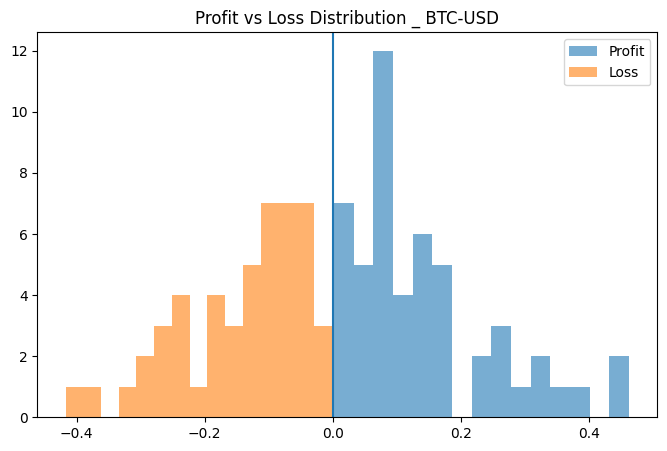


Asset: ETH-USD | Weight: 35.0%
Probability Profit: 0.5
Profit Analysis: {'count': 50, 'mean_profit': 0.1859101710504282, 'max_profit': 0.5300199825339621, 'min_profit': 0.0010492905887320271, 'mean_max_drawdown': -0.11392539598983173}
Loss Analysis: {'count': 50, 'mean_loss': -0.1844007164456657, 'worst_loss': -0.5327589767863417, 'smallest_loss': -0.002158965308265272}


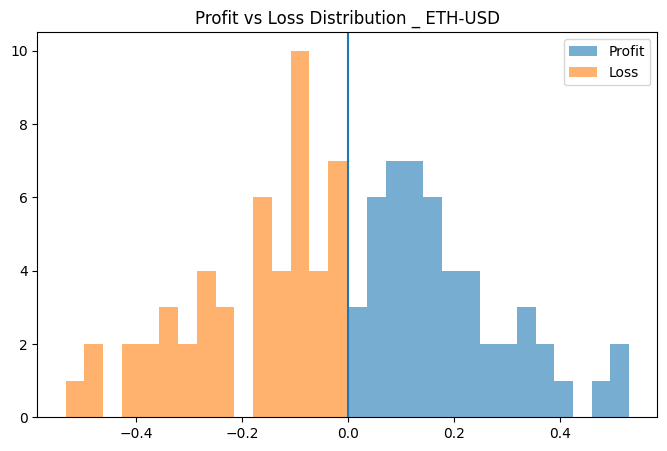


Asset: ADA-USD | Weight: 25.0%
Probability Profit: 0.51
Profit Analysis: {'count': 51, 'mean_profit': 0.20362785271871936, 'max_profit': 0.6675983032050786, 'min_profit': 0.013620850042750179, 'mean_max_drawdown': -0.13179149819072894}
Loss Analysis: {'count': 49, 'mean_loss': -0.1988696611260714, 'worst_loss': -0.5097193131809239, 'smallest_loss': -0.024453624782297616}


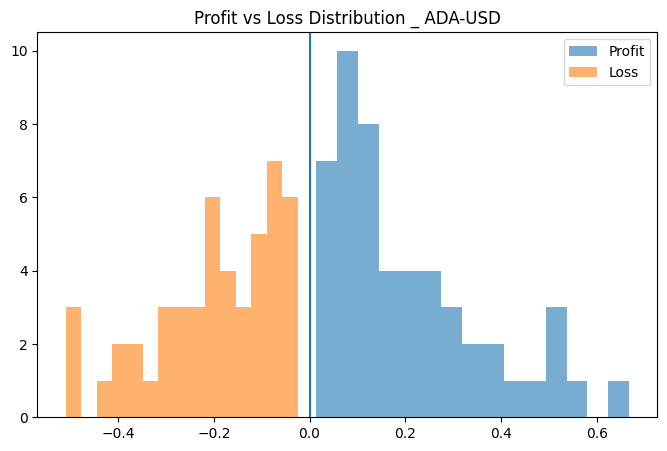

In [20]:
from core.pipelines.scenario_engine import ScenarioEngine, ScenarioConfig
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np





results = {}

for ticker, weight in user_input["assets"].items():
    print(f"\n============================")
    print(f"Asset: {ticker} | Weight: {weight*100:.1f}%")
    
    # load features
    symbol = ticker.replace("-USD", "")
    features_path = f"data/processed/features/{symbol}_features.csv"
    df = pd.read_csv(features_path)
    
    # scenario engine
    engine = ScenarioEngine(features_df=df)
    
    out = engine.run(
        ScenarioConfig(
            asset=ticker,
            horizon_days=user_input["horizon_days"],
            n_scenarios=user_input["n_scenarios"],
            model_type="quantile_ml_walk_forward",
        )
    )
    
    metrics = out["metrics"]
    
    results[ticker] = {
        "weight": weight,
        "metrics": metrics,
        "paths": out["paths"],
    }
    
    print("Probability Profit:", metrics["prob_profit"])
    print("Profit Analysis:", metrics["profit_analysis"])
    print("Loss Analysis:", metrics["loss_analysis"])
 

    returns = np.log(out["paths"][:, -1] / out["paths"][:, 0])

    plt.figure(figsize=(8,5))
    plt.hist(returns[returns>0], bins=15, alpha=0.6, label="Profit")
    plt.hist(returns[returns<0], bins=15, alpha=0.6, label="Loss")
    plt.axvline(0)
    plt.legend()
    plt.title("Profit vs Loss Distribution _ " + ticker)
    plt.show()

   


## Step 6: Regime Detection and Historical Matching (W7)

This step uses an AI model (PyTorch Autoencoder) to learn a latent representation for rolling windows, then uses KNN with cosine distance to retrieve top-n most similar historical windows. After the matches are found, we evaluate forward outcomes over the user horizon (profit and max drawdown).

We will do:
6-1) Train regime models for all coins from data/raw/metadata/coins.json and save to artifacts/models/<TICKER>/
6-2) For user-selected coins, load saved models and run regime matching, then print the output

In [21]:
import os
import json
from pprint import pprint

from core.regime_detection.regime_detection import run_regime_historical_matching

#### Step 6 Config

In [22]:
MATCH_WINDOW_DAYS = 30
TOP_N = 10

# User input at runtime
HORIZON_DAYS = user_input["horizon_days"]

SIMILARITY_METRIC = "cosine"
EMBARGO_DAYS = 5

LATENT_DIM = 16
TRAIN_EPOCHS = 40

#### Helper: map ticker to features file

In [23]:
def ticker_to_features_path(ticker: str) -> str:
    # Example: BTC-USD -> BTC -> data/processed/features/BTC_features.csv
    base = ticker.split("-")[0]
    return f"data/processed/features/{base}_features.csv"

#### 6-1 Train models for all coins in coins.json

In [24]:
coins_path = "data/raw/metadata/coins.json"
with open(coins_path, "r", encoding="utf-8") as f:
    coins = json.load(f)

# Normalize coins into a list
if isinstance(coins, dict):
    if "coins" in coins and isinstance(coins["coins"], list):
        coins_list = coins["coins"]
    else:
        coins_list = list(coins.values())
else:
    coins_list = coins

tickers = []
for c in coins_list:
    t = c.get("yahoo_ticker") 
    if t:
        tickers.append(t)

print("Total tickers found:", len(tickers))
print("First 5 tickers:", tickers[:5])

trained = []
skipped = []

for t in tickers:
    features_path = ticker_to_features_path(t)

    if not os.path.exists(features_path):
        skipped.append((t, features_path))
        continue

    out = run_regime_historical_matching(
        features_csv_path=features_path,
        ticker=t,
        match_window_days=MATCH_WINDOW_DAYS,
        top_n=TOP_N,
        horizon_days=HORIZON_DAYS,
        similarity_metric=SIMILARITY_METRIC,
        embargo_days=EMBARGO_DAYS,
        latent_dim=LATENT_DIM,
        train_epochs=TRAIN_EPOCHS,
        force_retrain=True,
    )

    trained.append(t)
    print(f"[OK] Trained and saved for {t}")

print("\nTRAINED:", len(trained))
print("SKIPPED (missing features):", len(skipped))
if skipped:
    print("Example skipped:", skipped[:5])

Total tickers found: 10
First 5 tickers: ['BTC-USD', 'ETH-USD', 'BNB-USD', 'XRP-USD', 'SOL-USD']
[AE] epoch 1/40 loss=0.764061
[AE] epoch 10/40 loss=0.292008
[AE] epoch 20/40 loss=0.259252
[AE] epoch 30/40 loss=0.248753
[AE] epoch 40/40 loss=0.240832
[OK] Trained and saved for BTC-USD
[AE] epoch 1/40 loss=0.824600
[AE] epoch 10/40 loss=0.303364
[AE] epoch 20/40 loss=0.258760
[AE] epoch 30/40 loss=0.248461
[AE] epoch 40/40 loss=0.240769
[OK] Trained and saved for ETH-USD
[AE] epoch 1/40 loss=0.823881
[AE] epoch 10/40 loss=0.310571
[AE] epoch 20/40 loss=0.257412
[AE] epoch 30/40 loss=0.240790
[AE] epoch 40/40 loss=0.232149
[OK] Trained and saved for BNB-USD
[AE] epoch 1/40 loss=0.778043
[AE] epoch 10/40 loss=0.300979
[AE] epoch 20/40 loss=0.251853
[AE] epoch 30/40 loss=0.233370
[AE] epoch 40/40 loss=0.222648
[OK] Trained and saved for XRP-USD
[AE] epoch 1/40 loss=0.905496
[AE] epoch 10/40 loss=0.336359
[AE] epoch 20/40 loss=0.284653
[AE] epoch 30/40 loss=0.257006
[AE] epoch 40/40 loss=0.

#### 6-2 ) Run for user selected coins (should load cached models)

In [25]:
regime_results = {}

for t , _ in user_input["assets"].items():
    features_path = ticker_to_features_path(t)

    if not os.path.exists(features_path):
        print(f"[WARN] Missing features file for {t}: {features_path}")
        continue

    out = run_regime_historical_matching(
        features_csv_path=features_path,
        ticker=t,
        match_window_days=MATCH_WINDOW_DAYS,
        top_n=TOP_N,
        horizon_days=HORIZON_DAYS,
        similarity_metric=SIMILARITY_METRIC,
        embargo_days=EMBARGO_DAYS,
        latent_dim=LATENT_DIM,
        train_epochs=TRAIN_EPOCHS,
        force_retrain=False,
    )

    regime_results[t] = out

    print("\n" + "=" * 90)
    print(f"REGIME MATCHING OUTPUT for {t}")
    print("used_cached_model:", out.get("used_cached_model"))
    print("\nCurrent window:")
    pprint(out["current_window"])
    print("\nSummary:")
    pprint(out["summary"])
    print("\nTop 3 matches:")
    for m in out["matches"][:3]:
        pprint(m)

print("\nDone.")


REGIME MATCHING OUTPUT for BTC-USD
used_cached_model: True

Current window:
{'current_window_end_date': '2026-02-26',
 'current_window_start_date': '2026-01-28',
 'horizon_days': 20,
 'match_window_days': 30,
 'ticker': 'BTC-USD',
 'top_n': 10}

Summary:
{'drawdown_analysis': {'mean_max_drawdown': -0.0631902724514111,
                       'worst_max_drawdown': -0.1160030734578148},
 'loss_analysis': {'count': 3,
                   'mean_loss': -0.019341454483293646,
                   'smallest_loss': -0.010135180313253445,
                   'worst_loss': -0.02956049620917567},
 'n_evaluated': 10,
 'prob_profit': 0.7,
 'profit_analysis': {'count': 7,
                     'max_profit': 0.328617112771451,
                     'mean_profit': 0.1616143048770453,
                     'min_profit': 0.052377548237920735}}

Top 3 matches:
{'candidate_window_idx': 297,
 'distance': 0.03545224666595459,
 'forward_end_date': '2015-09-28',
 'forward_end_index': 346,
 'horizon_days': 20,
 'max_

# Step 7: Risk assessment and Portfolio allocation (W8)

In [31]:
from core.risk import RiskConfig, compute_risk
from core.portfolio import PortfolioConstraints, build_portfolio

# 1) Convert user_input risk_tolerance to 0..100
rt = user_input.get("risk_tolerance", 50)

if isinstance(rt, str):
    # map labels to 0..100
    rt_map = {
        "Conservative": 20,
        "Moderate": 50,
        "Aggressive": 80,
    }
    user_rt = rt_map.get(rt, 50)
else:
    # if user gives 0..1 like 0.49 then convert to 49
    user_rt = float(rt)
    if 0.0 <= user_rt <= 1.0:
        user_rt *= 100.0

# 2) Build scenario dict expected by compute_risk and build_portfolio
scenario_outputs = {}
risks = {}

risk_cfg = RiskConfig(confidence_levels=[0.95])

for ticker in user_input["assets"].keys():
    m = results[ticker]["metrics"]

    scenario_outputs[ticker] = {
        "asset": ticker,
        "summary": {"horizon_days": user_input["horizon_days"]},
        "metrics": m,
    }

    risks[ticker] = compute_risk(scenario_outputs[ticker], risk_cfg)

# 3) Build portfolio
constraints = PortfolioConstraints(
    user_risk_tolerance=user_rt,
    top_k=len(user_input["assets"]),   # only allocate among user selected assets
    max_weight_per_asset=0.70,
    min_weight_per_asset=0.00,
    allow_cash=False,
)

portfolio = build_portfolio(scenario_outputs, risks, constraints)

print("User risk tolerance (0..100):", user_rt)
print("\nSuggested weights:")
for k, v in portfolio.weights.items():
    print(f"  {k}: {v:.4f}")

print("\nDetails:")
for d in portfolio.details:
    print(
        f"{d.symbol} | w={d.weight:.4f} | mu={d.expected_return_mean:.4f} | "
        f"p_profit={d.prob_profit:.2f} | cvar={d.cvar:.4f} | mdd={d.max_drawdown_est:.4f} | score={d.score:.4f}"
    )

User risk tolerance (0..100): 95.0

Suggested weights:
  BTC-USD: 0.3524
  ADA-USD: 0.3248
  ETH-USD: 0.3228

Details:
BTC-USD | w=0.3524 | mu=0.0029 | p_profit=0.51 | cvar=-0.3442 | mdd=-0.1367 | score=-0.2539
ADA-USD | w=0.3248 | mu=0.0064 | p_profit=0.51 | cvar=-0.4554 | mdd=-0.1866 | score=-0.3355
ETH-USD | w=0.3228 | mu=0.0008 | p_profit=0.50 | cvar=-0.4619 | mdd=-0.1720 | score=-0.3417
